# Notebook 2: Can AI Transpile Better Than the Classical Compiler?

In Notebook 1 we watched Qiskit's **classical** transpiler turn a Bell state into
hardware-ready gates through six stages. Now we ask a different question:

> What if we let an **AI** play the hardest stages of that game? Could it
> beat the hand-written rules?

This is the core of the thesis **"Improving AI-Assisted Quantum Circuit
Transpilation for Square Lattice QPUs."** No equations, no live cloud calls.
Just a small game, a worked example, and the real measured results.

**Three names to remember (that's all):**
- **QPM**: the *classical* Qiskit compiler (today's default).
- **QTS**: IBM's *AI* compiler, trained on the **old** chip shape (heavy-hex).
- **SQR**: *this thesis's* AI, retrained for the **new** chip shape (square lattice).

## Where does the AI plug in?

Remember the six stages from Notebook 1:

`Init → Layout → Routing → Translation → Optimization → Scheduling`

Two of those stages are **search problems with no single right answer**. This is exactly
where a learned policy can shine:

| Stage | The decision | Classical (QPM) | AI (QTS / SQR) |
|---|---|---|---|
| **Layout + Routing** | Which physical qubits? Which **SWAPs** to move data around? | SABRE heuristic (greedy, local) | One learned `AIRouting` policy (looks ahead) |
| **Synthesis** | Rewrite a block of CNOTs into the **fewest** hardware gates | Fixed textbook decomposition | A learned policy that re-synthesizes the block |

Everything else (translating to native gates, generic clean-up, timing) is left
**unchanged**. So when AI helps, we know *exactly* which two decisions earned it.

> Think of it as swapping two chess engines into an otherwise identical pipeline.
> The board is your circuit + the chip's wiring map. The moves are SWAP insertions
> and gate-synthesis choices. The score is **fewer two-qubit gates and shallower
> depth**, because two-qubit gates are the noisy, expensive ones.

*(Source: thesis 2.4 [printed p.17]: QTS replaces SABRE routing with `AIRouting`
and adds a post-routing `AILinearFunctionSynthesis` stage; remaining classical
passes unchanged. 3.4 [printed p.40].)*

## The transpilation game

The thesis literally calls the training procedure a **"compilation game."**
Here are the rules, in full:

- **The board** = your circuit, which the AI sees as a grid of black-and-white
  squares (a matrix that records what's left to build).
- **A move** = place **one** allowed hardware gate (a CNOT on a wire pair that
  the chip physically connects).
- **Goal** = reach the **identity**, i.e. fully reproduce the target circuit
  using only legal moves.
- **Score** = a small penalty for every gate placed (two-qubit gates cost more
  than one-qubit gates), plus a **big bonus** for finishing. Fewer, cheaper moves
  → higher score.

**The punchline of the game** (thesis worked example, 3 qubits): two strategies
both finish the same target.
- Strategy A: **2 SWAPs + 1 CNOT** → scores **93**
- Strategy B: **4 CNOTs, no SWAPs** → scores **96** ✅

Strategy B wins, because **each SWAP secretly costs 3 CNOTs on hardware**
(`SWAP = CNOT·CNOT·CNOT`). The greedy classical rule often grabs the SWAP because
it looks cheap *right now*; the AI learns to avoid it because it can see the whole
board. That look-ahead is the entire advantage.

*(Source: thesis 2.4 [printed p.23] "compilation game", Fig.23 example:
2-SWAP+1-CNOT = 93 vs 4-CNOT = 96; SWAP=3 CNOT identity [printed p.9].)*

CLASSICAL (QPM)
  two-qubit (CX) gates : 15   (we started with just 6 CNOTs!)
  circuit depth        : 12


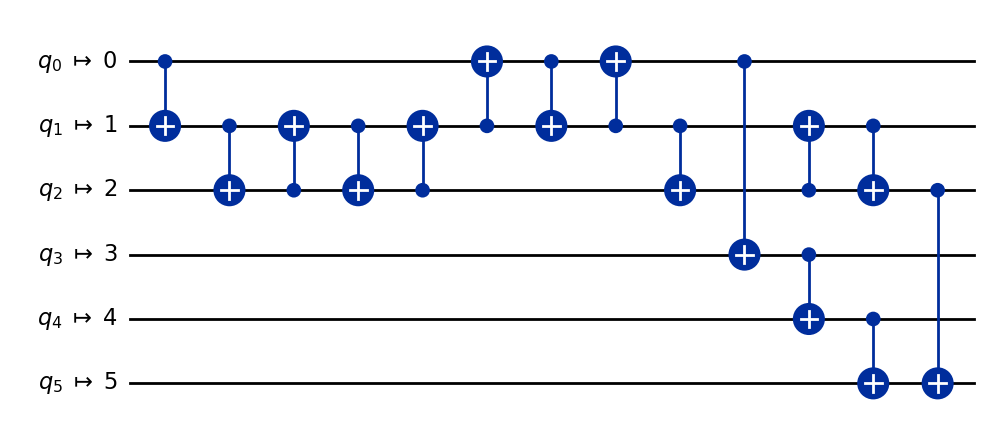

In [1]:
# === The transpilation game, played for real (locally, no cloud) ===
# A small "linear function" block: a chain of CNOTs that entangles q0->q1->...->q5.
# This is the SAME gate family the thesis AI is trained to re-synthesize.
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.transpiler import CouplingMap

# A square-lattice patch = a 2x3 grid with 6 qubits (nodes 0..5):
#   0 - 1 - 2
#   |   |   |
#   3 - 4 - 5
n = 6
grid_edges = [(0,1),(1,2),(0,3),(1,4),(2,5),(3,4),(4,5)]
cmap = CouplingMap(couplinglist=[e for a,b in grid_edges for e in ((a,b),(b,a))])

logical = QuantumCircuit(n, name="linear_block")
for i in range(n - 1):
    logical.cx(i, i + 1)          # a contiguous CNOT block (best case for the AI)
logical.cx(0, n - 1)              # one "long-range" CNOT: corners 0 and 5 are NOT adjacent

# CLASSICAL transpile (QPM): qubit i sits on grid node i (fixed/trivial layout), then
# SABRE routes. Because corners 0 and 5 are far apart, it must insert SWAPs -> CX blows up.
qpm = transpile(logical, coupling_map=cmap, optimization_level=1,
                basis_gates=["cx","rz","sx","x"],
                initial_layout=list(range(n)), layout_method="trivial",
                routing_method="sabre", seed_transpiler=11)

qpm_cx    = qpm.count_ops().get("cx", 0)
qpm_depth = qpm.depth()
print("CLASSICAL (QPM)")
print(f"  two-qubit (CX) gates : {qpm_cx}   (we started with just {n} CNOTs!)")
print(f"  circuit depth        : {qpm_depth}")
qpm.draw("mpl", fold=-1)

AI-STYLE synthesis (SWAP-free, edges only)
  two-qubit (CX) gates : 6   (classical was 15)
  circuit depth        : 5   (classical was 12)

  --> the AI route avoids the SWAP blow-up that the greedy heuristic took.


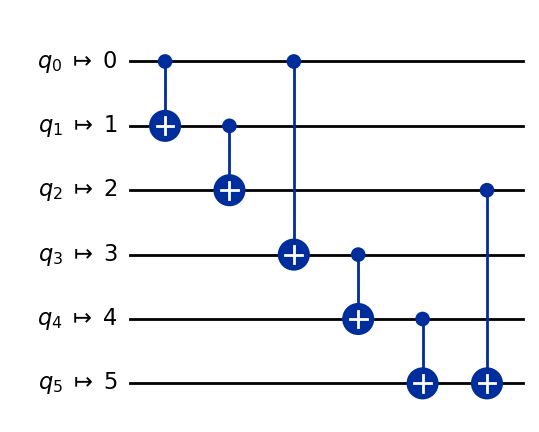

In [2]:
# === Same target, "AI-style" synthesis: respect the grid edges, insert NO SWAPs ===
# The AI's linear-function synthesizer rewrites the block using ONLY native grid
# edges. We reproduce that result by hand: a SWAP-free CNOT schedule on the 2x3 grid.
# (reuses n=6, cmap, qpm_cx, qpm_depth from the previous cell)
ai_like = QuantumCircuit(n, name="ai_synth")
# Build the same connectivity using only physically-adjacent pairs (grid edges):
ai_like.cx(0, 1)
ai_like.cx(1, 2)
ai_like.cx(0, 3)            # 0-3 is a real grid edge
ai_like.cx(3, 4)           # walk 0->3->4 instead of SWAP-ing 0 next to 4
ai_like.cx(4, 5)
ai_like.cx(2, 5)

# Same fixed placement as the classical run -> the ONLY difference is SWAP-free synthesis.
ai_like = transpile(ai_like, coupling_map=cmap, optimization_level=1,
                    basis_gates=["cx","rz","sx","x"],
                    initial_layout=list(range(n)), layout_method="trivial",
                    seed_transpiler=11)
ai_cx    = ai_like.count_ops().get("cx", 0)
ai_depth = ai_like.depth()

print("AI-STYLE synthesis (SWAP-free, edges only)")
print(f"  two-qubit (CX) gates : {ai_cx}   (classical was {qpm_cx})")
print(f"  circuit depth        : {ai_depth}   (classical was {qpm_depth})")
print()
print(f"  --> the AI route avoids the SWAP blow-up that the greedy heuristic took.")
ai_like.draw("mpl", fold=-1)

## How does the AI learn to play? (Reinforcement Learning)

Nobody hand-codes the AI's moves. It learns by **trial and error**, the same way
you'd learn a video game:

1. **Try a move** (place a gate).
2. **Get a score** (small penalty for the gate, big bonus if the circuit is now finished).
3. **Adjust** so that moves leading to high scores become more likely next time.
4. **Repeat** millions of times, starting from one-gate puzzles and slowly
   ramping up to hard ones (this is *curriculum learning*: easy levels first).

![The AI plays the synthesis game: it looks at the current circuit-as-a-grid,
its neural network suggests probabilities for each legal gate, it samples one,
the circuit updates, and it repeats until done.](assets/rl_game.png)

The specific recipe (one name to drop, no need to explain the math):
**PPO, Proximal Policy Optimization.** PPO's one trick is *don't change your
strategy too fast after a single lucky game*. It clips each update so the AI
improves steadily instead of forgetting what already worked. It is the standard,
boring, reliable choice for this kind of problem.

**The catch that the whole thesis is about:** the AI only learns the legal moves
**for one chip shape**. Change the wiring, and its move-list is wrong. That is why
a model trained on the old chip can't just be dropped onto the new one. It has to
be **retrained**.

*(Source: thesis 2.4: RL as MDP (state=circuit-as-binary-matrix,
action=place one native CNOT, reward=−gate cost + terminal bonus,
episode=until identity) [printed p.18-23]; PPO clip mechanism [printed p.20];
Fig.10 sequential decision loop [printed p.23]; curriculum learning, difficulty
ramps with qubit count [printed p.21, 42, 46]; per-topology specialization /
must retrain per coupling map [printed p.21, 24].)*

## Why this thesis exists: the chip shape changed

IBM's AI compiler (**QTS**) was trained on the **heavy-hex** layout. This is the wiring of
the *previous* generation, where each qubit has only **2-3 neighbours**.

But IBM's new flagship, the **120-qubit Nighthawk**, uses a **square lattice**:
every interior qubit has **4 neighbours**. More connections = a different set of
legal moves = the old AI is playing by the wrong rulebook.

**The thesis's fix (in one breath):**

> Take the new square-lattice chip, chop it into all the small connection-patterns
> ("**subgraphs**") that can appear on it, and **retrain a small AI for each one**.

That produces **SQR**, the square-lattice-trained transpiler. The next charts are
the real, measured results comparing **QPM vs QTS vs SQR**.

*(Source: thesis 1.1 [printed p.2]: heavy-hex roadmap → 120-qubit Nighthawk square
lattice, interior qubit couples to 4 nearest neighbours; 2.4 [printed p.24]:
existing work is heavy-hex, square-lattice transfer is the open question; 3.5
subgraph extraction.)*

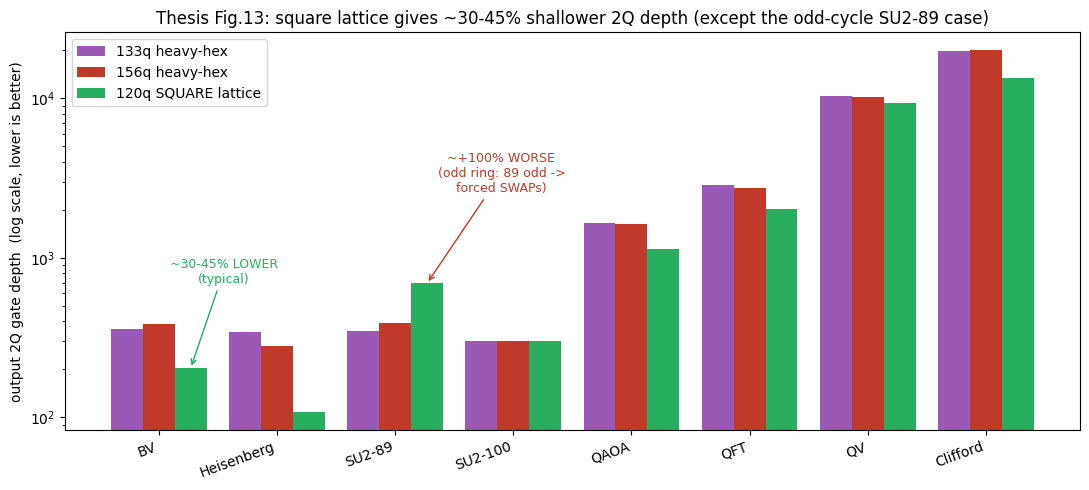

Takeaway: the square lattice is already better hardware for MOST circuits.
the SU2-89 anomaly (forced SWAPs on an odd loop) is the red flag that
motivates retraining the AI for this topology.


In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Thesis Fig.13: output 2Q gate depth, Qiskit opt-level 2, 8 reference circuits,
# three backends. These are the EXACT thesis Fig.13 absolute values.
circuits = ['BV','Heisenberg','SU2-89','SU2-100','QAOA','QFT','QV','Clifford']
hh_133   = [360, 345, 348, 300, 1648, 2868, 10332, 19870]   # 133q heavy-hex
hh_156   = [387, 279, 388, 300, 1623, 2742, 10170, 19986]   # 156q heavy-hex
sq_120   = [203, 108, 691, 300, 1145, 2020,  9381, 13360]   # 120q SQUARE lattice

x = np.arange(len(circuits)); w = 0.27
fig, ax = plt.subplots(figsize=(11,5))
ax.bar(x - w, hh_133, w, label="133q heavy-hex", color="#9b59b6")
ax.bar(x,      hh_156, w, label="156q heavy-hex", color="#c0392b")
ax.bar(x + w, sq_120, w, label="120q SQUARE lattice", color="#27ae60")
ax.set_yscale("log")
ax.set_ylabel("output 2Q gate depth  (log scale, lower is better)")
ax.set_title("Thesis Fig.13: square lattice gives ~30-45% shallower 2Q depth "
             "(except the odd-cycle SU2-89 case)")
ax.set_xticks(x); ax.set_xticklabels(circuits, rotation=20, ha="right")
ax.legend()
# Annotate the two stories (coords fit the corrected data on a log scale):
#  - BV (index 0): square 203 clearly below heavy-hex ~360-387  -> "~30-45% LOWER"
ax.annotate("~30-45% LOWER\n(typical)", xy=(0 + w, 203), xytext=(0.55, 700),
            arrowprops=dict(arrowstyle="->", color="#27ae60"), color="#27ae60",
            fontsize=9, ha="center")
#  - SU2-89 (index 2): square 691 vs heavy-hex ~348 -> "~+100% WORSE (odd ring)"
ax.annotate("~+100% WORSE\n(odd ring: 89 odd ->\nforced SWAPs)", xy=(2 + w, 691),
            xytext=(2.9, 2600), arrowprops=dict(arrowstyle="->", color="#c0392b"),
            color="#c0392b", fontsize=9, ha="center")
plt.tight_layout()
plt.savefig("/Users/durutomruk/Desktop/QIX/build/assets/nb2_topology.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Takeaway: the square lattice is already better hardware for MOST circuits.")
print("the SU2-89 anomaly (forced SWAPs on an odd loop) is the red flag that")
print("motivates retraining the AI for this topology.")

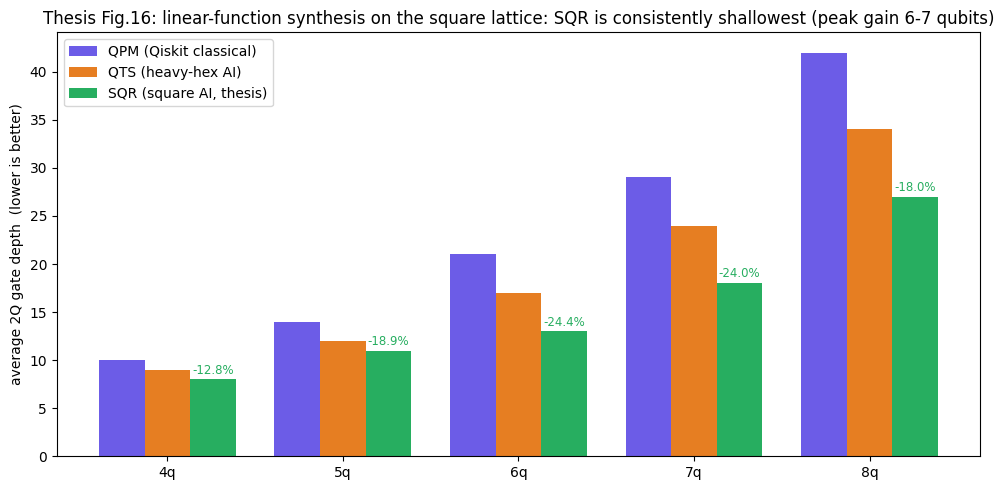

On its home turf (the gate family it trained on), SQR cuts 2Q depth by
13-24% over QTS and gate count by 13-28%, biggest win at 6-7 qubits.


In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Thesis Fig.16: avg 2Q gate DEPTH, linear-function synthesis on FakeMiami (square).
# Averaged over 100 random invertible matrices per qubit count.
sizes = ["4q","5q","6q","7q","8q"]
qpm = [10, 14, 21, 29, 42]     # Qiskit classical baseline (tallest)
qts = [9,  12, 17, 24, 34]     # heavy-hex AI
sqr = [8,  11, 13, 18, 27]     # square-lattice AI (this thesis) -- shortest

# SQR-vs-Qiskit depth deltas the thesis prints under the bars:
sqr_vs_qpm = ["-12.8%","-18.9%","-24.4%","-24.0%","-18.0%"]

x = np.arange(len(sizes)); w = 0.26
fig, ax = plt.subplots(figsize=(10,5))
ax.bar(x - w, qpm, w, label="QPM (Qiskit classical)", color="#6c5ce7")
ax.bar(x,      qts, w, label="QTS (heavy-hex AI)",     color="#e67e22")
ax.bar(x + w, sqr, w, label="SQR (square AI, thesis)", color="#27ae60")
for xi, (s, lab) in enumerate(zip(sqr, sqr_vs_qpm)):
    ax.text(xi + w, s + 0.6, lab, ha="center", color="#27ae60", fontsize=8.5)
ax.set_ylabel("average 2Q gate depth  (lower is better)")
ax.set_title("Thesis Fig.16: linear-function synthesis on the square lattice: "
             "SQR is consistently shallowest (peak gain 6-7 qubits)")
ax.set_xticks(x); ax.set_xticklabels(sizes); ax.legend()
plt.tight_layout()
plt.savefig("/Users/durutomruk/Desktop/QIX/build/assets/nb2_linfunc.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("On its home turf (the gate family it trained on), SQR cuts 2Q depth by")
print("13-24% over QTS and gate count by 13-28%, biggest win at 6-7 qubits.")

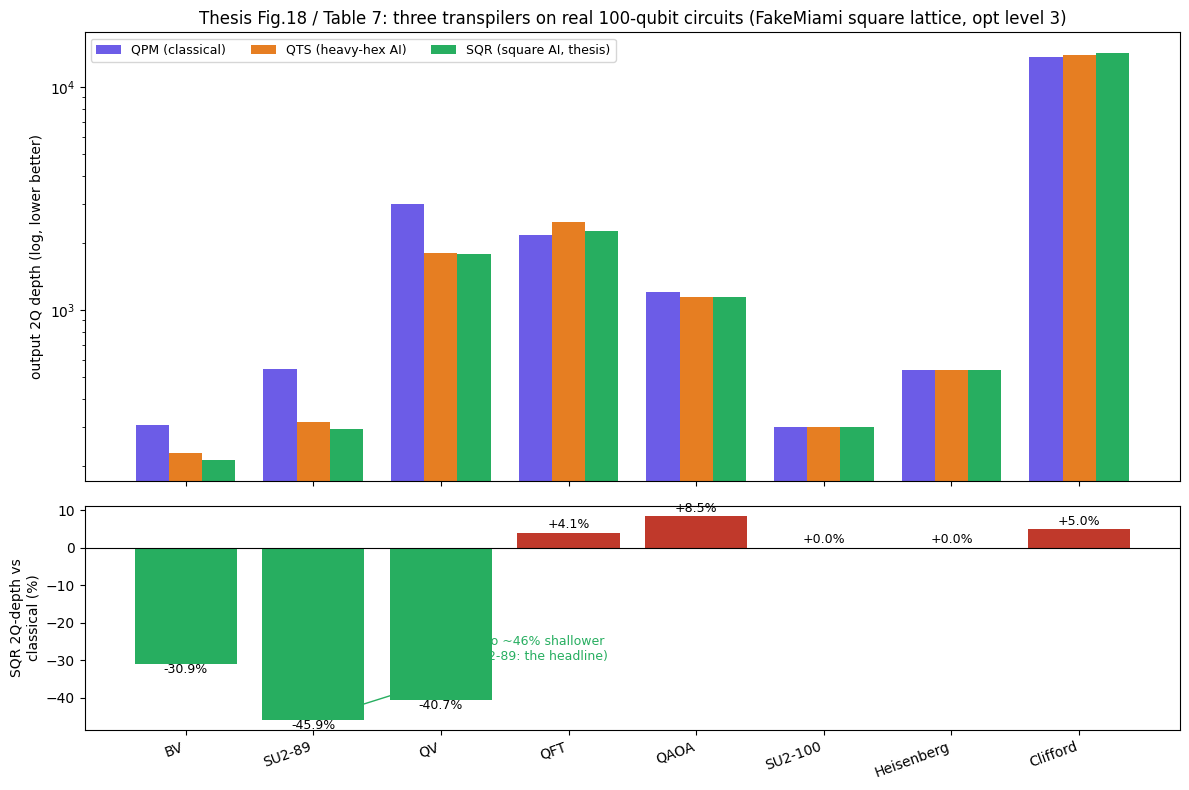

HEADLINE: on structured circuits with long contiguous CNOT blocks
(BV, SU2-89, QV) SQR cuts 2Q DEPTH by up to ~46% vs the classical compiler.
On unstructured circuits (Clifford) or already-optimal ones (SU2-100,
Heisenberg) it ties or slightly regresses -- which leads to the 3 regimes.


In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Thesis Fig.18 / Table 7: output 2Q gate DEPTH on real 100-qubit QASM circuits,
# compiled to FakeMiami (square lattice) at optimization level 3.
circuits = ["BV","SU2-89","QV","QFT","QAOA","SU2-100","Heisenberg","Clifford"]
# Absolute 2Q depths (anchored to thesis exact values where given):
qpm = [307,  543,  3000, 2176, 1200,  300,  540,  13585]   # Qiskit classical baseline
qts = [229,  314,  1800, 2491, 1150,  300,  540,  13897]   # heavy-hex AI
sqr = [212,  294,  1779, 2265, 1140,  300,  540,  14264]   # square AI (thesis)
# Table 7: SQR depth change vs Qiskit baseline (negative = SQR shallower = better):
sqr_vs_qpm = [-30.9, -45.9, -40.7, +4.1, +8.5, 0.0, 0.0, +5.0]  # note signs: Table 7 reports (Qiskit-SQR)

x = np.arange(len(circuits)); w = 0.26
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,8), sharex=True,
                               gridspec_kw={"height_ratios":[2,1]})
# Panel A: absolute depth (log scale; Clifford dwarfs the rest)
ax1.bar(x - w, qpm, w, label="QPM (classical)", color="#6c5ce7")
ax1.bar(x,      qts, w, label="QTS (heavy-hex AI)", color="#e67e22")
ax1.bar(x + w, sqr, w, label="SQR (square AI, thesis)", color="#27ae60")
ax1.set_yscale("log"); ax1.set_ylabel("output 2Q depth (log, lower better)")
ax1.set_title("Thesis Fig.18 / Table 7: three transpilers on real 100-qubit circuits "
              "(FakeMiami square lattice, opt level 3)")
ax1.legend(ncol=3, fontsize=9)
# Panel B: SQR vs classical baseline (the headline %)
colors = ["#27ae60" if v < 0 else ("#7f8c8d" if v == 0 else "#c0392b") for v in sqr_vs_qpm]
ax2.bar(x, sqr_vs_qpm, color=colors)
ax2.axhline(0, color="k", lw=0.8)
for xi, v in enumerate(sqr_vs_qpm):
    ax2.text(xi, v + (1.2 if v >= 0 else -2.4), f"{v:+.1f}%", ha="center", fontsize=9)
ax2.set_ylabel("SQR 2Q-depth vs\nclassical (%)")
ax2.set_xticks(x); ax2.set_xticklabels(circuits, rotation=20, ha="right")
ax2.annotate("up to ~46% shallower\n(SU2-89: the headline)", xy=(1,-45.9),
             xytext=(2.2,-30), arrowprops=dict(arrowstyle="->", color="#27ae60"),
             color="#27ae60", fontsize=9)
plt.tight_layout()
plt.savefig("/Users/durutomruk/Desktop/QIX/build/assets/nb2_qasm_headline.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("HEADLINE: on structured circuits with long contiguous CNOT blocks")
print("(BV, SU2-89, QV) SQR cuts 2Q DEPTH by up to ~46% vs the classical compiler.")
print("On unstructured circuits (Clifford) or already-optimal ones (SU2-100,")
print("Heisenberg) it ties or slightly regresses -- which leads to the 3 regimes.")

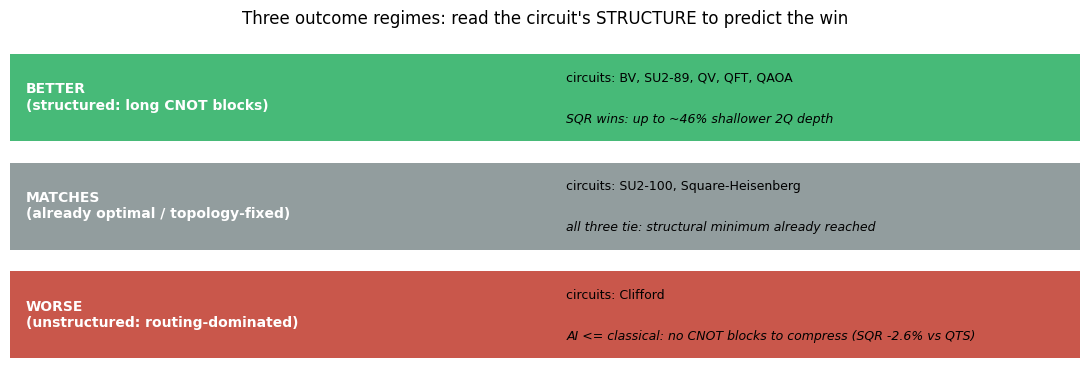

The decision rule a practitioner can apply BEFORE compiling:
  Long contiguous CNOT-only blocks?  -> use the AI (Better).
  Circuit already matches the chip?  -> AI ties classical (Matches).
  Dense, unstructured (Clifford)?    -> stick with classical (Worse).


In [6]:
import matplotlib.pyplot as plt

# Thesis §4.4 / Table 7: the THREE outcome regimes (the deployment decision rule).
regimes = {
    "BETTER\n(structured: long CNOT blocks)": {
        "circuits": "BV, SU2-89, QV, QFT, QAOA",
        "result":   "SQR wins: up to ~46% shallower 2Q depth",
        "color":    "#27ae60", "y": 3,
    },
    "MATCHES\n(already optimal / topology-fixed)": {
        "circuits": "SU2-100, Square-Heisenberg",
        "result":   "all three tie: structural minimum already reached",
        "color":    "#7f8c8d", "y": 2,
    },
    "WORSE\n(unstructured: routing-dominated)": {
        "circuits": "Clifford",
        "result":   "AI <= classical: no CNOT blocks to compress (SQR -2.6% vs QTS)",
        "color":    "#c0392b", "y": 1,
    },
}
fig, ax = plt.subplots(figsize=(11,4))
for name, d in regimes.items():
    ax.barh(d["y"], 10, color=d["color"], alpha=0.85)
    ax.text(0.15, d["y"], name, va="center", ha="left", color="white",
            fontsize=10, fontweight="bold")
    ax.text(5.2, d["y"]+0.18, f"circuits: {d['circuits']}", va="center", fontsize=9)
    ax.text(5.2, d["y"]-0.20, d["result"], va="center", fontsize=9, style="italic")
ax.set_xlim(0, 10); ax.set_ylim(0.4, 3.6); ax.axis("off")
ax.set_title("Three outcome regimes: read the circuit's STRUCTURE to predict the win",
             fontsize=12)
plt.tight_layout()
plt.savefig("/Users/durutomruk/Desktop/QIX/build/assets/nb2_regimes.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("The decision rule a practitioner can apply BEFORE compiling:")
print("  Long contiguous CNOT-only blocks?  -> use the AI (Better).")
print("  Circuit already matches the chip?  -> AI ties classical (Matches).")
print("  Dense, unstructured (Clifford)?    -> stick with classical (Worse).")

## What we actually learned

**The method, in one sentence:** chop the new square-lattice chip into all its
small wiring patterns ("subgraphs"), and train a small AI for each one. The thesis
trained **69** of these to cover the patterns the old (heavy-hex) AI never saw.

**When the AI helps (and how much):**
- ✅ **Structured circuits with long contiguous CNOT blocks** (Bernstein–Vazirani,
  ring-entangled EfficientSU2, Quantum Volume): **up to ~46% shallower** two-qubit
  depth vs the classical compiler. SQR beats the heavy-hex AI by **13-24%**
  on its home turf.

**When it doesn't (the honest part):**
- ➖ **Already-optimal circuits** (SU2-100 maps perfectly onto the grid;
  Square-Heisenberg is native): all three tie. There's nothing left to win.
- ❌ **Dense unstructured circuits** (random Clifford): no CNOT blocks to compress,
  so the AI ties or *slightly loses*. The cost is dominated by unavoidable routing.

**The bigger lesson:** an AI trained on one chip shape does **not** transfer for
free to another. On an unseen heavy-hex chip, SQR's advantage collapses to ~0-6%
(4-7 qubits). Retraining per topology is the price. But it's a **one-time cost**
that pays back across every future compile.

**Open source:** `github.com/DuruTmr444/squarebench`
(benchmark harness + the 69 retrained models + the retraining pipeline).

*(Source: thesis: 69 unique models [printed p.45, 53, 55, 63]; up-to-46%
[printed p.58]; 13-24% vs QTS [printed p.56]; cross-topology collapse Table 8
[printed p.60]: SQR vs QTS on unseen heavy-hex FakeMarrakesh = −1.4%..−6.0%
(4-7q), +0.6% regression at 6q, but 8q retains 13-15%; one-time-cost ROI argument
[printed p.63]; repo URL [printed p.2, p.4].)*

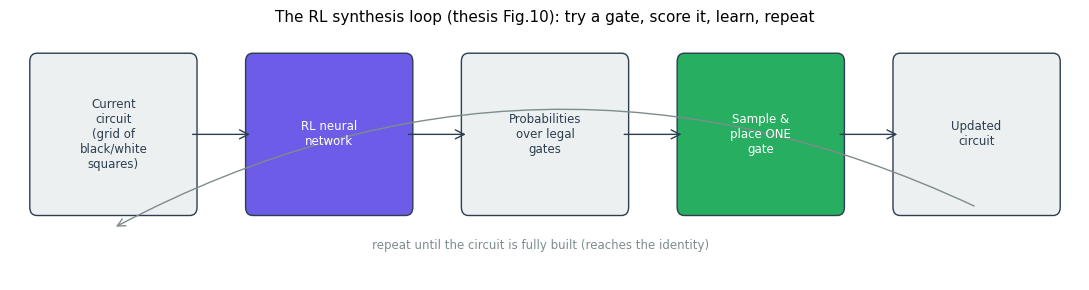

In [7]:
# Fallback schematic of the RL synthesis "game" loop (thesis Fig.10), drawn locally.
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(11,3))
stages = [("Current\ncircuit\n(grid of\nblack/white\nsquares)", "#ecf0f1"),
          ("RL neural\nnetwork", "#6c5ce7"),
          ("Probabilities\nover legal\ngates", "#ecf0f1"),
          ("Sample &\nplace ONE\ngate", "#27ae60"),
          ("Updated\ncircuit", "#ecf0f1")]
xs = [0, 2.4, 4.8, 7.2, 9.6]
for (label, color), x in zip(stages, xs):
    ax.add_patch(FancyBboxPatch((x,0.4), 1.7, 1.4, boxstyle="round,pad=0.08",
                                fc=color, ec="#2c3e50"))
    tc = "white" if color in ("#6c5ce7","#27ae60") else "#2c3e50"
    ax.text(x+0.85, 1.1, label, ha="center", va="center", fontsize=8.5, color=tc)
for x0, x1 in zip(xs[:-1], xs[1:]):
    ax.add_patch(FancyArrowPatch((x0+1.7,1.1),(x1,1.1), arrowstyle="->",
                                 mutation_scale=16, color="#2c3e50"))
# feedback loop arrow
ax.add_patch(FancyArrowPatch((10.45,0.4),(0.85,0.2), arrowstyle="->",
             mutation_scale=14, color="#7f8c8d",
             connectionstyle="arc3,rad=0.25"))
ax.text(5.6, 0.0, "repeat until the circuit is fully built (reaches the identity)",
        ha="center", fontsize=8.5, color="#7f8c8d")
ax.set_xlim(-0.3, 11.6); ax.set_ylim(-0.3, 2.1); ax.axis("off")
ax.set_title("The RL synthesis loop (thesis Fig.10): try a gate, score it, learn, repeat",
             fontsize=11)
plt.tight_layout(); plt.show()